# Taller Sesión 1 · Pensar con datos, trabajar con IA
## Metodologías y herramientas para la analítica y visualización de datos
**Maestría en Analítica de Datos para Contabilidad y Auditoría — Universidad Externado de Colombia**
Profesor: Yefry Moncada Linares

---

### El caso: Comercializadora Andina S.A.S.

Somos el equipo de analítica de **Comercializadora Andina S.A.S.**, una empresa que vende insumos a 40 clientes de cinco sectores (Retail, Construcción, Servicios, Manufactura y Agroindustria) en cinco ciudades de Colombia. La gerencia financiera nos entregó la **facturación completa del año 2025** (775 facturas) y nos hizo cuatro preguntas:

| Pregunta de la gerencia | Tipo de analítica |
|---|---|
| ¿Cómo se comportaron las ventas y la cartera en 2025? | **Descriptiva** — ¿qué pasó? |
| ¿Por qué cayeron las ventas en agosto? | **Diagnóstica** — ¿por qué pasó? |
| ¿Cuánto venderemos el próximo trimestre y quién pagará tarde? | **Predictiva** — ¿qué pasará? |
| ¿A qué clientes debemos llamar primero para cobrar? | **Prescriptiva** — ¿qué debemos hacer? |

En este taller responderemos las cuatro, y de paso aprenderemos Python, pandas y a trabajar con la IA como copiloto.

> ⚙️ **Antes de empezar:** ejecuta cada celda con `Shift + Enter`. Sube el archivo `facturacion_andina_2025.csv` usando el ícono de carpeta 📁 del panel izquierdo de Colab (o arrástralo).

---
# Parte 0 · Python exprés en 15 minutos

Python es un lenguaje de programación de propósito general, y hoy el estándar en ciencia de datos. No necesitas memorizar sintaxis: necesitas **entender lo suficiente para leer código, pedírselo bien a la IA y verificar lo que devuelve**.

Cuatro ideas bastan para arrancar: variables, listas, diccionarios y funciones.

In [3]:
# 1. VARIABLES: cajas con nombre donde guardamos valores
empresa = "Comercializadora Andina S.A.S."   # texto (string)
anio = 2025                                   # número entero (int)
ventas_totales = 10_332_000_000               # los guiones bajos son solo para leer mejor
tiene_cartera_vencida = True                  # booleano (verdadero/falso)

# f-string: la forma moderna de armar textos con variables adentro
print(f"{empresa} facturó ${ventas_totales:,.0f} COP en {anio}")

Comercializadora Andina S.A.S. facturó $10,332,000,000 COP en 2025


este codigo lo que hace es crear cada variable, la variable se crea con un nombre que deseo darle y el = para texto es importante siempre que vaya en "" los nombres de las variables siempre van con _ y puedo usar operadores boleanos como true o false basicamente pregunta si la cartera esta vencida devuelva el resultado a verdadero, ahora la funcion f me permite crear varias variables de texto con variables de numero donde print devuelve el resultado llamando al nombre de la empresa el uso de $ especifica la variable que deseo traer y se adiciona el año, se puede observar que la funcion print(f trae las comillas de inicio a fin para que el resultado que devuelva sea un texto)

In [2]:
# 2. LISTAS: colecciones ordenadas (como una columna de Excel)
ciudades = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Bucaramanga"]

print(ciudades[0])        # la posición empieza en 0, no en 1
print(len(ciudades))      # cuántos elementos tiene
print(ciudades[-1])       # el último elemento

Bogotá
5
Bucaramanga


lo que se hace es crear una variable donde se concatena diferentes categorias que en este caso son texto, las ciudades donde se venden van a quedar creadas como si fueran columnas, print siempre sera el resultado que queremos obtener puedo saber a traves de las posiciones cual es la 1 ciudad sin embargo la posicion no es 1 como creeriamos si no empieza en 0 es impotrtante que siempre tenga [] los corchetes para que resultado que queremos obtener lo traiga, y -1 para revision de ultimo elemento

In [1]:
# 3. DICCIONARIOS: pares clave → valor (como una tabla de dos columnas)
ventas_por_sector = {
    "Retail": 2450,
    "Construcción": 2890,
    "Servicios": 1120,
}
print(ventas_por_sector["Construcción"])   # buscamos por la clave

# 4. FUNCIONES: recetas reutilizables
def en_millones(valor_cop):
    """Convierte un valor en pesos a millones, redondeado."""
    return round(valor_cop / 1_000_000)

print(en_millones(10_332_000_000), "millones")

2890
10332 millones


la funcion def en millones va crear como una "caja" para que cuando se pida el resultado con print incluya en la variable el valor que deseamos convertir y despues lo que hara es que con el return round va a redondear esa cifra y la va a dividir en 1.000.000, adicional le puedo agregar texto como "millones al final del resultado"

> 💡 **Eso es todo el Python "de memoria" que necesitas hoy.** Todo lo demás lo iremos leyendo y entendiendo sobre la marcha — y para eso está la IA. La regla del curso:
>
> ### 🥇 Regla de oro: *la IA escribe, tú verificas contra la cifra que ya conoces.*

---
# Parte 1 · Cargar los datos con pandas

**pandas** es la librería de Python para trabajar con tablas. Piensa en ella como *Excel con esteroides*: las mismas ideas (filas, columnas, filtros, tablas dinámicas), pero programables, reproducibles y sin límite práctico de tamaño.

Su objeto central es el **DataFrame**: una tabla con nombre de columnas.

el codigo esta generando un error el cual informa No module named "pandas" para poder siempre ejecutar codigos las librerias deben estar ejecutadas, por lo que la correremos para que se pueda ejecutar el codigo y crear el data frame

In [7]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 22.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 43.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


ahora al ejecutar python no encuentra el archivo facturacion_andina_2025.CVS por lo que vamos a validar cual es su verdadera ruta o carpeta donde esta el archivo

In [11]:
import os  #### esta herramienta me permite trabajar con archivos y carpetas de mi computador
print(os.getcwd()) ### me indica en que carpeta estoy trabajando
os.listdir() #### me indica que archivos y carpetas hay en la carpeta donde estoy trabajando

/workspaces/clase-1-externado


['Taller_Sesion1_Analitica_Andina (1).ipynb',
 'facturacion andina',
 'README.md',
 '.git']

aca podemos observar que cuando ejecutamos el codigo trae el nombre facturacion_andina_2025.csv pero en nuestro entorno cuando se cargo el archivo quedo con el nombre facturacion andina asi se llama la carpeta por lo que lo modificaremos para que el codigo funcione

In [7]:
import pandas as pd               # pandas casi siempre se importa con el alias "pd"

df = pd.read_csv("facturacion andina/facturacion_andina_2025.csv")   # leer el archivo a un DataFrame

# Convertimos las columnas de fecha a tipo fecha (vienen como texto)
for col in ["fecha_emision", "fecha_vencimiento", "fecha_pago"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df.head()                          # primeras 5 filas: nuestro primer vistazo

,factura_id,fecha_emision,fecha_vencimiento,fecha_pago,cliente_id,cliente,sector,ciudad,vendedor,dias_credito,valor_factura,estado
0,F2025-0001,2025-01-03,2025-02-02,2025-02-01,C038,Química Industrial CB,Manufactura,Cali,D. Torres,30,20000000,pagada
1,F2025-0002,2025-01-10,2025-02-09,2025-02-09,C018,Ingeniería y Concreto,Construcción,Cali,D. Torres,30,32400000,pagada
2,F2025-0003,2025-01-28,2025-03-14,2025-03-08,C007,Servicios Logísticos Andinos,Servicios,Medellín,L. Vargas,45,3900000,pagada
3,F2025-0004,2025-01-24,2025-02-23,2025-03-03,C034,Muebles Modernos,Manufactura,Barranquilla,C. Peña,30,14900000,pagada
4,F2025-0005,2025-01-04,2025-02-03,2025-02-10,C026,Calzado Bucaramanga,Manufactura,Bogotá,D. Torres,30,15000000,pagada


este codigo nos permite revisar que el archivo cargo correctamente estoy usando un ciclo for para que con el COL vaya recorra y  convierta los valores de la columna actual espeficamente las de fechas estan en texto y necesitamos dejarlas reconocibles por pandas para que la pueda comparar y utilizar para calcular, ahora es importante que la variable traiga errors="coerce" ya que esta funcion recorre y le indica a la libreria que si encuentra un valor vacio o una fecha invalida lo convierta en un valor NAT y por ultima con la funcion head traemos las primeras 5 lineas del archivo para validar en una vista rapida que se haya cargado correctamente y que las funciones solicitadas si se hayan aplicado correctamente.

In [8]:
# Radiografía básica del dataset
print("Filas y columnas:", df.shape)
print()
df.info()          # tipos de datos y valores no nulos por columna

Filas y columnas: (775, 12)

<class 'pandas.DataFrame'>
RangeIndex: 775 entries, 0 to 774
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   factura_id         775 non-null    str           
 1   fecha_emision      775 non-null    datetime64[us]
 2   fecha_vencimiento  775 non-null    datetime64[us]
 3   fecha_pago         740 non-null    datetime64[us]
 4   cliente_id         775 non-null    str           
 5   cliente            775 non-null    str           
 6   sector             775 non-null    str           
 7   ciudad             775 non-null    str           
 8   vendedor           775 non-null    str           
 9   dias_credito       775 non-null    int64         
 10  valor_factura      775 non-null    int64         
 11  estado             775 non-null    str           
dtypes: datetime64[us](3), int64(2), str(7)
memory usage: 72.8 KB


recordemos que print siempre sera la funcion para que me traiga los resultados que quiero, como la base ya cargo quiero verificar que las 12 columnas del archivo en que clase estan y saber si esta limpia la base de datos podemos observar que las columnas estan en las clases correctas que las de texto que se ven como STR sean efectivamente textuales las cuales todas cumplen ese parametro lo mismo datetime64 que las columnas que albergan fechas las tengan y int64 para las columnas con numeros enteros que me permiten luego crear funciones de suma, multiplicacion ETC y no tendran ningun error, puedo observar que las clases de la base estan correctamente clasificadas, adicional y lo mas importante el non-null me esta indicando que la columna fecha pago tiene 35 celdas nulas o con valores vacios el resto de columnas tienen sus celdas diligenciadas 

In [9]:
df.isna().sum()

factura_id            0
fecha_emision         0
fecha_vencimiento     0
fecha_pago           35
cliente_id            0
cliente               0
sector                0
ciudad                0
vendedor              0
dias_credito          0
valor_factura         0
estado                0
dtype: int64

creamos esta funcion que es amigable donde efectivamente se reconfirma que hay 35 celdas en la columna fecha_pago con valores faltantes

In [11]:
# describe(): estadísticos de resumen de las columnas numéricas
df["valor_factura"].describe().apply(lambda x: f"{x:,.0f}")

count           775
mean     13,330,916
std       8,724,407
min       1,600,000
25%       7,250,000
50%      10,900,000
75%      16,150,000
max      68,700,000
Name: valor_factura, dtype: str

este codigo me permite validar los valores estadisticos de la tabla en un primer vistazo llama la atencion que el rango intercuartilico esta entre 7.250.000 y 16.150.000 en su 75% tenemos un valor maximo de 68.700.000 que supera totalmente este rango, vamos a validar con un codigo adicional el limite superior para saber en un primer vistazo si hay probabilidad que la base tiene datos atipicos.

In [12]:
q1 = df["valor_factura"].quantile(0.25)
q3 = df["valor_factura"].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

df[df["valor_factura"] > limite_superior][
    ["factura_id", "cliente", "valor_factura"]
]

,factura_id,cliente,valor_factura
1,F2025-0002,Ingeniería y Concreto,32400000
24,F2025-0025,Acabados y Pinturas,32100000
31,F2025-0032,Acabados y Pinturas,34200000
42,F2025-0043,Constructora Horizonte,47800000
75,F2025-0076,Química Industrial CB,30500000
76,F2025-0077,Lácteos San Fernando,30700000
78,F2025-0079,Ingeniería y Concreto,34300000
80,F2025-0081,Calzado Bucaramanga,31800000
89,F2025-0090,Acabados y Pinturas,32200000
111,F2025-0112,Constructora Horizonte,39900000


con esta funcion del rango intercuartilico establecimos el limite superior de los cuales me muestran las facturas mas altas, no significan que sean valores atipicos pero si me da indicios de que son valores analizar en la base de datos mas adelante

**🔎 Verifica como contador:** ¿el total facturado coincide con lo que reportó la gerencia (~$10.300 millones)? Compruébalo tú mismo — esta es la actitud que mantendremos con todo resultado, lo genere pandas o lo genere una IA.

In [13]:
total = df["valor_factura"].sum()
print(f"Total facturado 2025: ${total:,.0f} COP  (≈ {total/1e6:,.0f} millones)")

Total facturado 2025: $10,331,460,000 COP  (≈ 10,331 millones)


la funcion total = df["valor_factura"].sum() me permite sumar toda la columna valor factura por eso se especifica en el codigo dando un resultado posterior con la funcion print donde vamos a combinar variables de texto y numeros pidiendo iniciar con el texto total facturado 2025, trae el total y convierte las cifras en decimales y separacion de comas y posterior convierte el total de pesos colombianos a millones, ahora conocer este dato nos permite dar un primer vistazo que la base puede tener informacion correcta ya que basicamente si coincide el total que nos dieron con el total encontrado hay una razonabilidad con la informacion compartida, sin embargo esto solo es un primer filtro pero debemos analizar toda la informacion de la base de datos 

Esta primera parte del taller nos ha permitido explorar los datos de las bases que las clases en cada columna sean las correctas, que la tabla este completa sabiendo su total de filas y columnas, evidenciar si existen valores nulos o en blanco, conocer estadisticamente como un vistazo rapido lo que tenemos en una base de datos donde vimos que hay facturas que superan el rango intercuatilico y ya nos da una primera impresion de que debemos validar y por ultimo que la informacion compartida por la gerencia coincidiera ya que nos da una señal que la base que recibimos tiene probablemente los datos correctos si que falten facturas por agregar o este incompleto

---
# Parte 2 · Analítica DESCRIPTIVA — ¿Qué pasó?

La analítica descriptiva **resume el pasado**: totales, promedios, tendencias, composición. Es el equivalente a los estados financieros: no explica causas ni anticipa nada, pero es la base de todo lo demás.

**Pregunta de la gerencia:** ¿cómo se comportaron las ventas y la cartera en 2025?

1. el codigo genera error y esto es debido a que hay una funcion que permite hacer graficos el error que sale es matplotlib is required for plotting when the default backend "matplotlib" is selected  por lo que vamos a instalar el paquete

In [15]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.3 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 28.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 21.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


<Axes: title={'center': 'Comercializadora Andina · Ventas mensuales 2025 (millones COP)'}, xlabel='mes'>

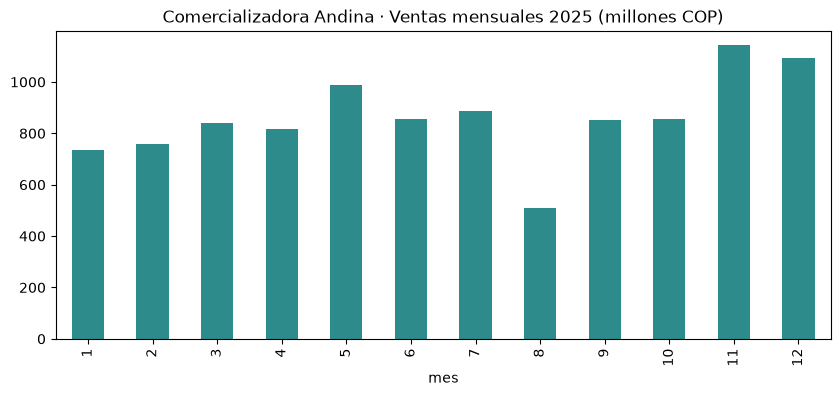

In [16]:
# Ventas por mes: la vista más básica del negocio
df["mes"] = df["fecha_emision"].dt.month

ventas_mes = df.groupby("mes")["valor_factura"].sum() / 1e6   # en millones

ventas_mes.plot(kind="bar", figsize=(10, 4), color="#2E8B8B",
                title="Comercializadora Andina · Ventas mensuales 2025 (millones COP)")

1. entender el codigo creado donde para saber el comportamiento de las ventas del año se parte por los 12 meses y asi poder determinar en que mes fueron mas altas o mas bajas por eso se tomo desde la columna fecha emision y se convirtio a meses con la funcion df.groupby se agrupo el mes con su valor total de la factura y la funcion. sum() me permite sumar el total de esa columna y con 1e6 que es la funcion de un millon para dividirlo y me lo cambie de pesos colombianos a miles de millones, luego se crear el plot que es el grafico con todas las expecificaciones como el tipo de grafico, su tamaño, el color de las barras y se agrega el titulo permitiendo que visualmente podamos realizar la analitica descriptiva


**Lee el gráfico como analista:** hay estacionalidad (picos en mayo y noviembre-diciembre)… y algo raro en **agosto**. Anótalo — volveremos a eso en la analítica diagnóstica.

ya tendiendo el grafico visualmente podemos ver que noviembre alberga la mayor parte de ventas del año seguido de diciembre y mayo, los meses de junio, septiembre y octubre mantienen sus ventas en la misma proporcion y con unos picos no tan elevados ni tan bajos en los meses de julio, abril y marzo, enero pero el que mayor preocupa es el mes de agosto que tuvo una caida de ventas relevante, ya en este punto me da una idea de que datos debo analizar, como por ejemplo la actividad economica de la empresa, fechas especiales las fechas que tienen mayor ventas se puede considerar por que son los meses que mas celebraciones tiene, recordemos que cuando exploramos la base de datos pudimos observar rapidamente facturas con valores altos fuera del rango intercuartilico por lo que tambien debemos entender la tendencia de esas facturas por que son mas altas que otras y probablemente esten dentro de los meses que el grafico muestra como mayores ventas, probablemente no se trate de mas cantidad de facturas si no de mayores valores facturados, sin embargo todo esto lo analizaremos mas adelante con otro tipo de analisis que si nos puede indicar que sucedio en esos meses.

In [17]:
# Composición: ¿qué sectores y clientes concentran la venta?
print("Ventas por sector (millones):")
print((df.groupby("sector")["valor_factura"].sum() / 1e6).round(0).sort_values(ascending=False))
print()
print("Top 5 clientes (millones):")
print((df.groupby("cliente")["valor_factura"].sum() / 1e6).round(0).sort_values(ascending=False).head(5))

Ventas por sector (millones):
sector
Manufactura      3364.0
Construcción     3156.0
Retail           2142.0
Agroindustria     889.0
Servicios         781.0
Name: valor_factura, dtype: float64

Top 5 clientes (millones):
cliente
Constructora Cimientos    522.0
Acabados y Pinturas       502.0
Ingeniería y Concreto     492.0
Química Industrial CB     460.0
Constructora Horizonte    459.0
Name: valor_factura, dtype: float64


Como vimos anteriormente en el grafico con solo ver el grafico no puedo sacar conclusiones de que pasa solo supocisiones para concentrame en los datos en este paso necesito preguntarme que paso que unos meses sean mas altos y especificamente el mes de agosto haya sido tan bajo por lo que vamos a empezar a descomponer la base, aqui estamos abriendo componentes por el sector, recordemos que la empresa vende a diferentes sectores, en este punto puedo observar que el sector manufactura lidera las ventas y el sector servicios es el que menos ventas tiene, sin embargo llama la atencion tambien aunque el sector construccion esta por debajo de manufactura tiene los mejores clientes para la compañia y aqui nuevamente vuelve el rango intercuartilico establecido la mayoria de ellos son los que tienen las facturas con valores mas altos, este punto tambien me da informacion que debo seguir analizando para llegar a las casusas de los picos elevados y bajos de las ventas. 

<Axes: title={'center': 'Aging de cartera al corte (millones COP)'}, xlabel='rango'>

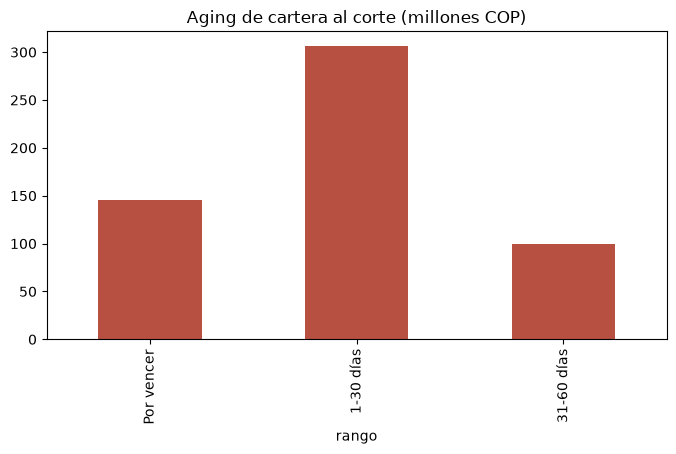

In [18]:
# Aging de cartera: clásico de contabilidad, ahora en 6 líneas
# Tomamos las facturas SIN pagar y las clasificamos por días de vencimiento
corte = pd.Timestamp("2026-01-31")
pendientes = df[df["fecha_pago"].isna()].copy()
pendientes["dias_vencida"] = (corte - pendientes["fecha_vencimiento"]).dt.days

rangos = [-9999, 0, 30, 60, 90, 9999]
etiquetas = ["Por vencer", "1-30 días", "31-60 días", "61-90 días", "Más de 90"]
pendientes["rango"] = pd.cut(pendientes["dias_vencida"], bins=rangos, labels=etiquetas)

aging = pendientes.groupby("rango", observed=True)["valor_factura"].sum() / 1e6
aging.plot(kind="bar", figsize=(8, 4), color="#B85042",
           title="Aging de cartera al corte (millones COP)")

ahora analizaremos la otra pregunta desde gerencia el comportamiento de la cartera, el codigo los define en grupos de edades por cartera para saber en que rango se concentra la mayor cartera, teniendo en cuenta las facturas que no tienen fecha de pago o esten en estado pendiente, tambien el codigo creo un .copy() para no afectar la verdadera base de datos, la concentracion de cartera solo me muestra por el valor de las ventas no la cantidad de facturas, podemo observar de 1 vistazo que hay una cartera sana pues la mayoria se concentra en los vencimientos de 1 a 30 dias no hay facturas pendientes mayor a 360 dias o mayor a 90 se podria decir que hay una buena gestion, luego validaremos y desglosaremos mas las facturas dentro de estos rangos. 

> 🤖 **IA-copiloto #1.** Pídele a tu asistente de IA:
> *"Tengo un DataFrame de pandas llamado `df` con las columnas `fecha_emision` (fecha), `ciudad` (texto) y `valor_factura` (número). Dame el código para una tabla dinámica con los meses en las filas, las ciudades en las columnas y la suma de `valor_factura` en millones en las celdas."*
>
> Pega el código en la celda de abajo, ejecútalo y **verifica**: ¿la suma de toda la tabla coincide con los ~$10.300 millones que ya conocemos?

In [19]:
# 👉 Pega aquí el código que te dio la IA y ejecútalo
tabla_ciudad_mes = (
    df.pivot_table(
        index="mes",
        columns="ciudad",
        values="valor_factura",
        aggfunc="sum",
        fill_value=0
    ) / 1e6
).round(1)

tabla_ciudad_mes

ciudad,Barranquilla,Bogotá,Bucaramanga,Cali,Medellín
mes,,,,,
1,150.2,119.0,37.1,192.9,236.5
2,152.2,141.8,162.1,154.8,147.1
3,124.1,117.5,184.8,214.1,201.5
4,81.5,198.1,149.1,150.1,236.4
5,268.4,215.7,131.8,188.6,182.4
6,126.4,133.6,96.7,272.7,226.3
7,185.5,179.3,89.9,254.9,175.6
8,125.7,109.7,129.8,71.9,73.9
9,242.3,185.0,41.6,193.1,188.8


In [20]:
print("Total de la tabla:", tabla_ciudad_mes.sum().sum(), "millones")
print("Total original:", df["valor_factura"].sum() / 1e6, "millones")

Total de la tabla: 10331.5 millones
Total original: 10331.46 millones


Con la funcion podemos analizar mas los datos al detalle desglosando ahora por ciudad, primero lo hicimos por sector y en este caso la ciudad aqui tambien otro punto de referencia analizar medellin y cali, venian con un mayor valor en ventas y en el mes de agosto las 2 ciudades bajaron bastante sus ventas y luego nuevamente se re incorporan, tambien se hace la validacion si la informacion que tomamos es correcta y no difiere de la base original solo por un pequeño numero de redondeos pero los totales coinciden con el valor de 10331.

En conclusion en este primer analisis descriptivo pudimos saber que 1. la empresa tuvo grandes ventas en los meses de noviembre, diciembre y mayo y una baja importante de ventas en el mes de agosto, donde se revisa la base por sector para saber que sectores son los que predominan vimos que el sector manufactura lidera las ventas y aunque es quien lidera el top el sector  construccion que en el alberga los clientes con mayor valor de ventas y que coincide con con el rango intercuartilico que analizamos en la exploracion de datos son los clientes que tienen facturas con valores altos, por ultimo tambien desglosamos las ciudades y pudimos ver que medellin y cali sus ventas en los primeros meses eran muy parecidas pero en el mes de agosto fueron las ciudades que menor valor de ventas registran y el valor tuvo una caida bastante sinificativa con el promedio que traian en el año

---
# Parte 3 · Analítica DIAGNÓSTICA — ¿Por qué pasó?

La analítica diagnóstica **busca causas**: descompone, compara, correlaciona. Es el trabajo del auditor cuando encuentra una variación inusual: *drill-down* hasta dar con la explicación.

**Pregunta de la gerencia:** ¿por qué cayeron las ventas en agosto?

In [21]:
# Paso 1: dimensionar el problema. ¿Qué tan grande fue la caída?
jul, ago = ventas_mes[7], ventas_mes[8]
print(f"Julio:  {jul:,.0f} millones")
print(f"Agosto: {ago:,.0f} millones")
print(f"Caída:  {jul - ago:,.0f} millones  ({(ago/jul - 1)*100:.1f}%)")

Julio:  885 millones
Agosto: 511 millones
Caída:  374 millones  (-42.3%)


1. entender el codigo lo que esta haciendo la funcion es tomar las ventas espcificamente del mes de julio donde venian estable las ventas y comparar con el mes de agosto que representa la caida y se usa la funcion dividiendo las ventas de agosto y julio y convirtiendola en % para saber de cuanto fue el impacto 
2. podemos observar que la caida del mes de agosto representa el 42.3% de las ventas casi la mitad de las ventas que obtienen por mes la entidad, por lo que el siguiente paso es descomponer que sector fue el que afecto esta caida

In [22]:
# Paso 2: descomponer. ¿La caída fue general o concentrada?
comparacion = (
    df[df["mes"].isin([7, 8])]
    .pivot_table(index="sector", columns="mes", values="valor_factura", aggfunc="sum")
    / 1e6
).round(0)
comparacion.columns = ["Julio", "Agosto"]
comparacion["Variación"] = comparacion["Agosto"] - comparacion["Julio"]
comparacion.sort_values("Variación")

,Julio,Agosto,Variación
sector,,,
Construcción,304.0,33.0,-271.0
Manufactura,292.0,186.0,-106.0
Agroindustria,67.0,39.0,-28.0
Retail,156.0,165.0,9.0
Servicios,66.0,88.0,22.0


el sector construccion es el que registra la mayor caida de ventas, recordemos que en la analitica descriptiva vimos que los sectores construccion y manufactura son los que lideran las ventas en la compañia y el sector construccion tiene los clientes con mayor valor en ventas y las facturas mas grandes por lo que ya empezamos a entender que tiene logica, el por que la caida esta representando casi la mitad de las ventas que tiene la compañia mensualmente, que no se hubiera visto tan significativa si hubiera estado relacionado con los demas sectores

<Axes: title={'center': 'Julio vs. Agosto por sector (millones COP): la caída está en Construcción'}, xlabel='sector'>

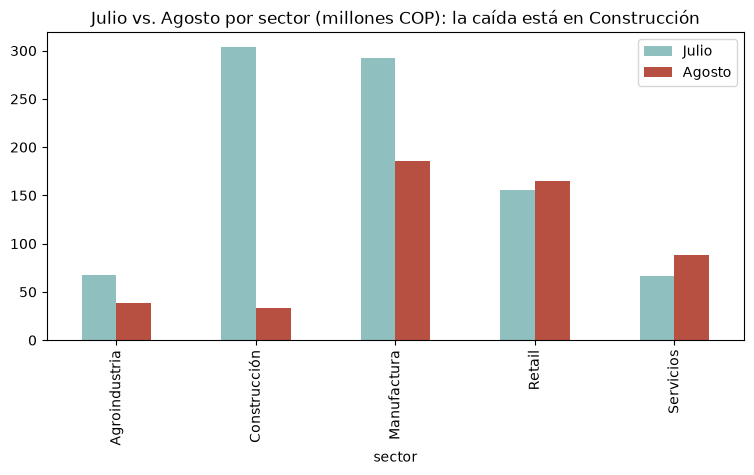

In [23]:
# Paso 3: visualizar el hallazgo
comparacion[["Julio", "Agosto"]].plot(kind="bar", figsize=(9, 4),
    color=["#8FBFBF", "#B85042"],
    title="Julio vs. Agosto por sector (millones COP): la caída está en Construcción")

con este grafico podemos observar visualmente que la caida de construccion frente al mes de julio es bastante significativa, vamos a crear una funcion por que ahora quiero saber que % representa la caida del sector construccion 

In [24]:
comparacion["Variación_%"] = (
    (comparacion["Agosto"] - comparacion["Julio"])
    / comparacion["Julio"]
    * 100
).round(1)

comparacion

,Julio,Agosto,Variación,Variación_%
sector,,,,
Agroindustria,67.0,39.0,-28.0,-41.8
Construcción,304.0,33.0,-271.0,-89.1
Manufactura,292.0,186.0,-106.0,-36.3
Retail,156.0,165.0,9.0,5.8
Servicios,66.0,88.0,22.0,33.3


In [25]:
caida_construccion = comparacion.loc["Construcción", "Variación_%"]

print(f"La variación de ventas en Construcción fue de {caida_construccion:.1f}%")

La variación de ventas en Construcción fue de -89.1%


con esto determinamos que cayo en 89% las ventas en el sector construccion en el mes de agosto, una caida bastante significativa,ahora debemos entender que paso y por que esta caida tan significativa representa un gran perdida para la compañia. 

**Conclusión diagnóstica:** la caída de agosto **no fue general**: se concentra casi por completo en el sector **Construcción** (~-270 millones), mientras los demás sectores se mantuvieron estables. El siguiente paso en la vida real sería hablar con el área comercial: ¿se pausaron obras?, ¿perdimos un cliente grande?, ¿fue un tema de precios?

> Observa el método: **dimensionar → descomponer → aislar → concluir**. La herramienta calcula; el criterio profesional pregunta y concluye.

> 🤖 **IA-copiloto #2.** Ahora hazlo tú con otra dimensión. Pídele a la IA el código para comparar julio vs. agosto **por ciudad** y **por vendedor**. ¿La caída de Construcción se concentra en alguna ciudad? Escribe tu conclusión en una frase.

In [27]:
# 👉 Tu drill-down por ciudad / vendedor aquí
# Comparación de ventas de julio y agosto por ciudad
comparacion_ciudad = (
    df[df["mes"].isin([7, 8])]
    .pivot_table(
        index="ciudad",
        columns="mes",
        values="valor_factura",
        aggfunc="sum",
        fill_value=0
    )
    / 1e6
).round(1)

comparacion_ciudad.columns = ["Julio", "Agosto"]

comparacion_ciudad["Variación"] = (
    comparacion_ciudad["Agosto"] - comparacion_ciudad["Julio"]
).round(1)

comparacion_ciudad["Variación_%"] = (
    comparacion_ciudad["Variación"]
    / comparacion_ciudad["Julio"]
    * 100
).round(1)

comparacion_ciudad.sort_values("Variación_%")

,Julio,Agosto,Variación,Variación_%
ciudad,,,,
Cali,254.9,71.9,-183.0,-71.8
Medellín,175.6,73.9,-101.7,-57.9
Bogotá,179.3,109.7,-69.6,-38.8
Barranquilla,185.5,125.7,-59.8,-32.2
Bucaramanga,89.9,129.8,39.9,44.4


In [28]:
comparacion_vendedor = (
    df[df["mes"].isin([7, 8])]
    .pivot_table(
        index="vendedor",
        columns="mes",
        values="valor_factura",
        aggfunc="sum",
        fill_value=0
    )
    / 1e6
).round(1)

comparacion_vendedor.columns = ["Julio", "Agosto"]

comparacion_vendedor["Variación"] = (
    comparacion_vendedor["Agosto"] - comparacion_vendedor["Julio"]
).round(1)

comparacion_vendedor["Variación_%"] = (
    comparacion_vendedor["Variación"]
    / comparacion_vendedor["Julio"]
    * 100
).round(1)

comparacion_vendedor.sort_values("Variación_%")

,Julio,Agosto,Variación,Variación_%
vendedor,,,,
D. Torres,196.8,70.4,-126.4,-64.2
A. Rojas,214.4,83.3,-131.1,-61.1
C. Peña,160.0,81.3,-78.7,-49.2
L. Vargas,221.2,141.5,-79.7,-36.0
J. Mora,92.8,134.5,41.7,44.9


Conclusion final: dimensionamos que el % de caida de las ventas partiendo de julio un mes estable en ventas y agosto nuestro mes de caida represento el 42,3% que es basicamente la mita de las ventas promedio que tiene la compañia mes a mes, es por eso que descompusimos de la base de datos por sector y en ella evidencias que el sector construccion represento la mayor caida que represento el 89% de sus ventas, recordando que el sector construccion es uno de los sectores lideres en las ventas de la compañia y tiene a los 5 clientes con mayor facturacion es por eso que el % de 42,3% de total de ventas de la compañia tiene logica la mayoria de las ventas se concentran en este sector , las ciudades mas afectadas son cali y medellin cali bajo en un 72% sus ventas y medellin en un 58% igualmente los vendedores D.torres y A rojas son los que reportan menor ventas y las que estan originando esta caida, por lo que debemos validar que llevo a que las ventas hayan caido tanto este mes.

---
# Parte 4 · Analítica PREDICTIVA — ¿Qué pasará? *(anticipo)*

La analítica predictiva usa el pasado para **estimar el futuro**: proyecciones, probabilidades, clasificaciones. En las sesiones 2 y 3 construiremos modelos formales (regresión, árboles); hoy hacemos dos versiones simples para entender la lógica.

**Preguntas de la gerencia:** ¿cuánto venderemos? ¿Quién pagará tarde?

Proyección ingenua para enero 2026: 1,030 millones
⚠️ ¿Qué problema le ves a proyectar enero con el promedio de nov-dic? (pista: estacionalidad)


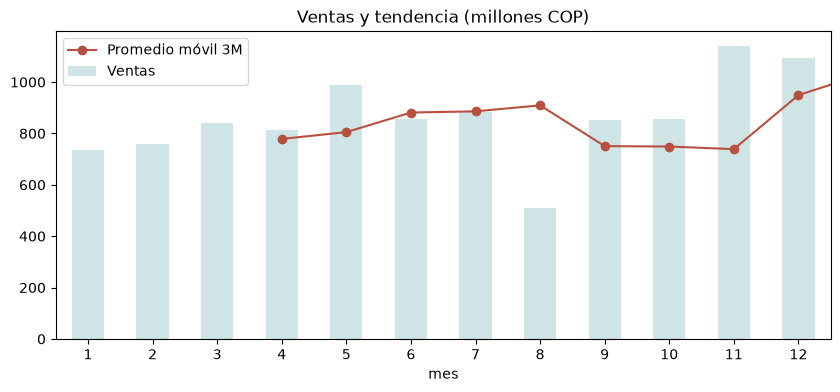

In [29]:
# Predicción ingenua #1: proyectar con el promedio móvil de 3 meses
promedio_movil = ventas_mes.rolling(3).mean()

ax = ventas_mes.plot(kind="bar", figsize=(10, 4), color="#CFE5E5", label="Ventas")
promedio_movil.plot(ax=ax, color="#B85042", marker="o", label="Promedio móvil 3M")
ax.set_title("Ventas y tendencia (millones COP)")
ax.legend()

print(f"Proyección ingenua para enero 2026: {promedio_movil.iloc[-1]:,.0f} millones")
print("⚠️ ¿Qué problema le ves a proyectar enero con el promedio de nov-dic? (pista: estacionalidad)")

1. entedamos el codigo esta prediccion ingenua para enero del 2026 esta tomando como base tres meses que son octubre, noviembre y diciembre, la funcion AX me permite mostrar la leyenda para distinguir las barras de ventas y la linea promedio movil esta funcion promedio_movil.iloc[-1]:,.0f esta seleccionando el promedio de octubre, noviembre y diciembre y los convierte a decimales y con separador de , 

2. Ahora esta proyeccion ingenua no seria la mas recomendada ya que, estamos tomando meses donde en el analisis descriptivo vimos que noviembre y diciembre representan la mayor parte de ventas probablemente por un tema de estacionalidad, sin embargo enero lo mas probable es que no se va a comportar de la misma manera, yo tomaria meses donde las ventas fueron mas estables en el año, adicional para una buena prediccion 1 tenemos que identificar lo que ocasiono la caida de ventas en agosto que me permita identificar que probablemente no sucedera o que se pueda repetir, 2 para una buena prediccion debo usar Backtesting tengo que entrenar datos historicos si vemos solo estamos analizando un año pero debemos preguntarnos como han sido las variaciones de los años anteriores, que genero el pico de caida de agosto, entre mas datos tenga mas informacion de entrenamiento tendre y puedo predecir posterior, adicional recordemos que en la exploracion de datos que hicimos inicialmente tenemos facturas grandes fuera del promedio de ventas, tambien debo validar si ocurrio este año o se viene presentando en todos los años, es demasiada informacion analizar antes de hacer una prediccion. 

In [30]:
# Predicción ingenua #2: ¿quién pagará tarde? El pasado como mejor predictor simple
pagadas = df[df["fecha_pago"].notna()].copy()
pagadas["dias_atraso"] = (pagadas["fecha_pago"] - pagadas["fecha_vencimiento"]).dt.days
pagadas["pago_tarde"] = pagadas["dias_atraso"] > 5    # tolerancia de 5 días

perfil = pagadas.groupby("cliente").agg(
    facturas=("factura_id", "count"),
    atraso_promedio=("dias_atraso", "mean"),
    prob_pago_tarde=("pago_tarde", "mean"),
).round(2)

perfil.sort_values("prob_pago_tarde", ascending=False).head(8)

,facturas,atraso_promedio,prob_pago_tarde
cliente,,,
Construred,16,37.12,1.00
Plásticos del Pacífico,19,39.53,1.00
Constructora Cimientos,18,36.61,1.00
Constructora Horizonte,20,34.45,0.95
Constructora Monserrate,13,36.62,0.92
Obras Civiles del Norte,13,31.08,0.92
Transportes El Rápido,13,6.54,0.54
Química Industrial CB,27,1.81,0.41


1. el codigo esta colocando unos dias de tolerancia para determinar la probabilidad de vencimiento en los pagos tarde que en este caso son 5 dias de tolerancia por ejemplo construred el 100% de las facturas pagadas por este cliente tuvieron mas de 5 dias de retraso pero si observamos casi todos pagan en menos de 40 dias el mas alto es plasticos del pacifico, por lo que tambien coincide con el analisis diagnostico de la cartera que la mayoria se concentra entre 1 a 60 dias por lo que no es una cartera critica

In [31]:
# Facturación total anual por cliente
facturacion_anual = (
    df.groupby("cliente")["valor_factura"]
    .agg(
        facturacion_anual="sum",
        total_facturas="count"
    )
)

# Unir la facturación anual con el comportamiento de pago
analisis_clientes = perfil.join(facturacion_anual, how="left")

# Ordenar por probabilidad histórica de pagar tarde
analisis_clientes = analisis_clientes.sort_values(
    "prob_pago_tarde",
    ascending=False
)

# Mostrar los ocho clientes con mayor probabilidad de pago tardío
analisis_clientes[
    [
        "facturas",
        "facturacion_anual",
        "total_facturas",
        "atraso_promedio",
        "prob_pago_tarde"
    ]
].head(8)

,facturas,facturacion_anual,total_facturas,atraso_promedio,prob_pago_tarde
cliente,,,,,
Construred,16,407100000,17,37.12,1.00
Plásticos del Pacífico,19,327300000,23,39.53,1.00
Constructora Cimientos,18,522080000,22,36.61,1.00
Constructora Horizonte,20,458520000,21,34.45,0.95
Constructora Monserrate,13,431200000,16,36.62,0.92
Obras Civiles del Norte,13,342800000,14,31.08,0.92
Transportes El Rápido,13,86600000,13,6.54,0.54
Química Industrial CB,27,459800000,27,1.81,0.41


creamos este codigo adicional con la ayuda de la IA para revisar algo y es cual es el total de facturacion en el año por los clientes y las que representan retraso y aqui vemos algo construred se le ha factura 17 facturas y 16 de ellas presentan retraso en promedio de pago de 37 dias, y en varias empresas tambien se evidencia que casi todas las facturacion del año presenta atraso por lo que es importante validar por que estos proveedores demoran tanto en sus pagos y mas sabemos que el sector construccion es uno de los sectores lideres para las empresas, y la mayoria de atrasos vienen de clientes de este sector. 

Ahora como mencionamos anteriormente estamos revisando informacion de un solo año para la prediccion pueda que estos mismo clientes no tenga ese comportamiento en años anteriores por lo que es importante entrenar esta informacion con datos historicos para una mejor prediccion. 

**Lectura:** hay clientes que pagan tarde **9 de cada 10 veces**, con atrasos promedio de más de un mes. Esa frecuencia histórica es, en esencia, una probabilidad estimada — el mismo concepto que en la sesión 2 refinaremos con una **regresión logística** que además tendrá en cuenta el sector, el monto y los días de crédito.

---
# Parte 5 · Analítica PRESCRIPTIVA — ¿Qué debemos hacer?

La analítica prescriptiva convierte el análisis en **decisión**: recomienda acciones y las prioriza según impacto. No basta saber quién probablemente pagará tarde: hay que decidir **a quién llamar primero** con un equipo de cobranza limitado.

Criterio de negocio: prioridad = **cartera pendiente** × **probabilidad de pago tardío**.

In [32]:
# Cartera pendiente por cliente
cartera = (df[df["fecha_pago"].isna()]
           .groupby("cliente")["valor_factura"].sum()
           .rename("cartera_pendiente"))

# Cruzamos con el perfil de comportamiento de pago
plan = perfil.join(cartera, how="inner").fillna(0)
plan["prioridad"] = (plan["cartera_pendiente"] * plan["prob_pago_tarde"] / 1e6).round(1)

plan_cobranza = plan.sort_values("prioridad", ascending=False).head(10)
plan_cobranza[["cartera_pendiente", "prob_pago_tarde", "atraso_promedio", "prioridad"]]

,cartera_pendiente,prob_pago_tarde,atraso_promedio,prioridad
cliente,,,,
Constructora Monserrate,126200000,0.92,36.62,116.1
Constructora Cimientos,81600000,1.00,36.61,81.6
Plásticos del Pacífico,57100000,1.00,39.53,57.1
Construred,28700000,1.00,37.12,28.7
Obras Civiles del Norte,27500000,0.92,31.08,25.3
Constructora Horizonte,17200000,0.95,34.45,16.3
Electrodomésticos La Rebaja,37300000,0.31,2.31,11.6
Acabados y Pinturas,30000000,0.35,2.71,10.5
Vidrios y Aluminios Cali,31200000,0.24,1.82,7.5


1. el codigo lo que quiere generar es un plan de cobranza donde pueda validar variables como la cartera pendiente, su proabilidad de pago y atras y creando prioridades de manera ascendente desde la cartera mas alta y atraso siginificativo, adicional crea un puntaje de prioridad para que los asesores sepan quienes son los clientes a los que se debe hacer gestion urgente. 

2. este plan es importante por que aca se combina deuda alta y la probabilidad de tener mayor riesgo de que el cliente pague tarde asegurando que la gestion de cartera se priorice a los clientes mas importantes 

3. viendo todos los analisis que hemos hecho hasta el momento tiene sentido que el sector construccion sea uno de los mas criticos en cuanto a ventas, y cartera la cartera tambien esta representada por estos clientes y aunque muchos no superan mas de los 40 dias de retraso que es algo positivo lo ideal es mejorar y bajar los dias de cartera 

**Este ranking es una prescripción**: el lunes en la mañana, el equipo de cobranza llama primero a los primeros de la lista. Nota la cadena completa que recorrimos:

**Descriptiva** (así está la cartera) → **Diagnóstica** (esto explica la caída) → **Predictiva** (estos probablemente pagarán tarde) → **Prescriptiva** (llamen en este orden).

> 🤖 **IA-copiloto #3.** El criterio de prioridad es discutible: ignora, por ejemplo, la antigüedad de la deuda. Pídele a la IA que te ayude a incorporar los días de vencimiento al puntaje (por ejemplo, ponderando más la cartera con más de 60 días) y compara si el ranking cambia. **Tú defines el criterio de negocio; la IA solo lo implementa.**

In [33]:
# 👉 Tu versión mejorada del puntaje de prioridad aquí
# Cartera pendiente total por cliente
cartera_total = (
    pendientes.groupby("cliente")["valor_factura"]
    .sum()
    .rename("cartera_pendiente")
)

# Cartera con más de 60 días de vencimiento
cartera_mayor_60 = (
    pendientes[pendientes["dias_vencida"] > 60]
    .groupby("cliente")["valor_factura"]
    .sum()
    .rename("cartera_mayor_60")
)

# Unir la información de comportamiento y cartera
plan_mejorado = (
    perfil
    .join(cartera_total, how="inner")
    .join(cartera_mayor_60, how="left")
    .fillna(0)
)

# Dar un peso 50% mayor a la cartera con más de 60 días
plan_mejorado["prioridad_mejorada"] = (
    (
        plan_mejorado["cartera_pendiente"]
        - plan_mejorado["cartera_mayor_60"]
    )
    * plan_mejorado["prob_pago_tarde"]
    + plan_mejorado["cartera_mayor_60"]
    * plan_mejorado["prob_pago_tarde"]
    * 1.5
) / 1e6

plan_mejorado["prioridad_mejorada"] = (
    plan_mejorado["prioridad_mejorada"].round(1)
)

plan_mejorado.sort_values(
    "prioridad_mejorada",
    ascending=False
).head(10)

,facturas,atraso_promedio,prob_pago_tarde,cartera_pendiente,cartera_mayor_60,prioridad_mejorada
cliente,,,,,,
Constructora Monserrate,13,36.62,0.92,126200000,0.0,116.1
Constructora Cimientos,18,36.61,1.00,81600000,0.0,81.6
Plásticos del Pacífico,19,39.53,1.00,57100000,0.0,57.1
Construred,16,37.12,1.00,28700000,0.0,28.7
Obras Civiles del Norte,13,31.08,0.92,27500000,0.0,25.3
Constructora Horizonte,20,34.45,0.95,17200000,0.0,16.3
Electrodomésticos La Rebaja,13,2.31,0.31,37300000,0.0,11.6
Acabados y Pinturas,17,2.71,0.35,30000000,0.0,10.5
Vidrios y Aluminios Cali,17,1.82,0.24,31200000,0.0,7.5


In [34]:
comparacion_prioridades = plan_mejorado[
    ["cartera_pendiente", "cartera_mayor_60",
     "prob_pago_tarde", "prioridad_mejorada"]
].sort_values("prioridad_mejorada", ascending=False)

comparacion_prioridades.head(10)

,cartera_pendiente,cartera_mayor_60,prob_pago_tarde,prioridad_mejorada
cliente,,,,
Constructora Monserrate,126200000,0.0,0.92,116.1
Constructora Cimientos,81600000,0.0,1.00,81.6
Plásticos del Pacífico,57100000,0.0,1.00,57.1
Construred,28700000,0.0,1.00,28.7
Obras Civiles del Norte,27500000,0.0,0.92,25.3
Constructora Horizonte,17200000,0.0,0.95,16.3
Electrodomésticos La Rebaja,37300000,0.0,0.31,11.6
Acabados y Pinturas,30000000,0.0,0.35,10.5
Vidrios y Aluminios Cali,31200000,0.0,0.24,7.5


con el codigo que me dio la IA podemos observar que el nivel de prioridad no cambio que hizo este codigo para comparlo con la tabla anterior, tomar las mismas variables pero adicional revisar si hay cartera mayor a 60 dias que no estuvieramos teniendo en cuenta dandole tambien un peso del 50% si hubiera cartera superior por lo que podemos ver que efectivamente no existe cartera superior a la ya conocida por lo que el nivel de prioridad sigue siendo igual y se recomienda que este sea el mismo para la gestion de cartera

Conclusion final: con este anilisis podemos determinar los clientes mas criticos con deudas elevadas y una posiibilidad o riesgo de no recuperar su cartera, permitiendo entregar al area de gestion los clientes que realmente necesitan atencion y seguimiento para que la validacion y recuperacion de la misma sea beneficiosa para la empresa 

---
# 🏆 Retos para cerrar (con IA, documentando tus prompts)

Resuélvelos en las celdas siguientes. Por cada reto, deja en un comentario **el prompt que usaste** y **cómo verificaste** el resultado. Así funcionará la bitácora de IA de los talleres calificados.

1. **Descriptiva:** ¿cuál vendedor facturó más en el año y cuál es su ticket promedio por factura?
2. **Diagnóstica:** noviembre y diciembre son los meses pico. ¿Qué sectores explican ese pico? ¿Es el mismo patrón en todas las ciudades?
3. **Predictiva:** calcula el atraso promedio por **sector**. ¿Qué sector es el de mayor riesgo de pago tardío?
4. **Prescriptiva:** la empresa quiere ofrecer descuento por pronto pago solo a 5 clientes. ¿A cuáles se lo ofrecerías y con qué criterio? Justifica en una frase.


In [36]:
# Reto 1
# Prompt usado: # "Asume el rol de analista de datos. Tengo un DataFrame llamado df
# con las columnas vendedor, valor_factura y factura_id. Calcula la
# facturación total anual, el número de facturas y el ticket promedio
# por vendedor. Ordena los vendedores de mayor a menor facturación."
# Verificación:
resultado_vendedores = (
    df.groupby("vendedor")
    .agg(
        facturacion_anual=("valor_factura", "sum"),
        total_facturas=("factura_id", "count"),
        ticket_promedio=("valor_factura", "mean")
    )
    .sort_values("facturacion_anual", ascending=False)
)

resultado_vendedores["facturacion_millones"] = (
    resultado_vendedores["facturacion_anual"] / 1e6
).round(1)

resultado_vendedores["ticket_promedio_millones"] = (
    resultado_vendedores["ticket_promedio"] / 1e6
).round(1)

resultado_vendedores


,facturacion_anual,total_facturas,ticket_promedio,facturacion_millones,ticket_promedio_millones
vendedor,,,,,
C. Peña,2344580000,161,1.456261e+07,2344.6,14.6
D. Torres,2226400000,166,1.341205e+07,2226.4,13.4
A. Rojas,2075760000,143,1.451580e+07,2075.8,14.5
L. Vargas,1977000000,158,1.251266e+07,1977.0,12.5
J. Mora,1707720000,147,1.161714e+07,1707.7,11.6


de este primer punto la el codigo esta 1 agrupando todas las facturas por vendedor que es nuestra variable principal y la que encabeza la pregunta, luego suma todas las facturas de cada vendedor, para el ticket promedio va a calcular con mean el promedio por cada factura del vendendor y luego va ordenar los vendedores desde el que mas factuto al que menos facturo si vemos la tabla trae un valor muy grande que casi no se puede leer por eso usa la formula para pasarlo a millones con 1e6 y me muestra un resultado mas amigable 

2. ya sabemos que con el codigo el vendedor que mas vendio fue C.peña pero llama la atencion que el vendedor A.rojas facturo solo 143 facturas su promedio es de 14.5 lo que indica que gestiono facturas de valores altos, en comparacion de D.torres que aunque facturo mas el promedio de facturacion es mas bajo que el de A.rojas, esto puede que no concluye que haya mala gestion ni buena gestion ya que todo tambien depende del sector donde esten ubicados los vendedores.

In [38]:
# Reto 2
# Prompt usado:
# "Asume el rol de analista de datos. Tengo un DataFrame llamado df
# con las columnas mes, sector, ciudad y valor_factura. Analiza las
# ventas de noviembre y diciembre: calcula el total por sector,
# determina qué sectores explican el pico y verifica si el patrón
# se repite en todas las ciudades. Expresa los valores en millones
# de pesos y calcula la participación porcentual."
# Ventas por sector en noviembre y diciembre
ventas_pico_sector = (
    df[df["mes"].isin([11, 12])]
    .groupby(["mes", "sector"])["valor_factura"]
    .sum()
    .unstack(fill_value=0)
    / 1e6
).round(1)

ventas_pico_sector



sector,Agroindustria,Construcción,Manufactura,Retail,Servicios
mes,,,,,
11,72.3,454.0,377.6,168.6,69.3
12,147.9,231.6,354.5,268.3,92.2


In [40]:
### participacion por sector
resumen_sector = (
    df[df["mes"].isin([11, 12])]
    .groupby("sector")["valor_factura"]
    .agg(
        ventas_pico="sum",
        facturas="count"
    )
    .sort_values("ventas_pico", ascending=False)
)

resumen_sector["participacion_%"] = (
    resumen_sector["ventas_pico"]
    / resumen_sector["ventas_pico"].sum()
    * 100
).round(1)

resumen_sector["ventas_pico_millones"] = (
    resumen_sector["ventas_pico"] / 1e6
).round(1)

resumen_sector

,ventas_pico,facturas,participacion_%,ventas_pico_millones
sector,,,,
Manufactura,732100000,51,32.7,732.1
Construcción,685600000,27,30.7,685.6
Retail,436900000,46,19.5,436.9
Agroindustria,220200000,20,9.8,220.2
Servicios,161500000,22,7.2,161.5


In [41]:
#### patron por ciudad y sector 
ventas_pico_ciudad_sector = (
    df[df["mes"].isin([11, 12])]
    .groupby(["ciudad", "sector"])["valor_factura"]
    .sum()
    .unstack(fill_value=0)
    / 1e6
).round(1)

ventas_pico_ciudad_sector

sector,Agroindustria,Construcción,Manufactura,Retail,Servicios
ciudad,,,,,
Barranquilla,0.0,54.3,249.9,63.2,24.3
Bogotá,0.0,184.2,169.7,53.1,46.5
Bucaramanga,156.5,0.0,68.1,88.2,73.1
Cali,63.7,173.9,122.8,167.4,0.0
Medellín,0.0,273.2,121.6,65.0,17.6


Revisando los sectores manufactura y construccion son los que representan el pico mas alto siendo noviembre el mayor y luego diciembre, con un % de participacion para el sector manufactura del 32,7% y en el de construccion de 30,7% revisando por ciudad y sectores medellin representa el mayor valor de ventas con 273 millones en el sector construccion y 249,9 en el sector de manufactura desde la ciudad de barranquilla, los dos sectores tiene un patron de ventas similar en las ciudades de bogota y cali un poco mas elevado en medellin el sector de construccion que el de manufactura, sin embargo llama la atencion que bucaramanga tuvo 0 facturacion en construccion y un valor en millones demasiado bajo en manufactura es estos meses y esta ciudad en esos mismos meses fortalecio el sector agroindustrial y el de servicios, probablemente esta ciudad se maneja mucho mejor en otros sectores, aunque los sectores estrella para la compañia sea manufactura y construccion. 

In [42]:
# Reto 3
# Prompt usado:
# "Asume el rol de analista de datos. Tengo un DataFrame llamado df
# con las columnas sector, fecha_vencimiento y fecha_pago.
# Calcula los días de atraso de las facturas pagadas, resume por sector
# el atraso promedio, el número de facturas y el porcentaje de facturas
# pagadas con más de 5 días de atraso. Ordena los sectores desde el
# mayor riesgo hasta el menor."

# Seleccionar únicamente facturas pagadas
pagadas_sector = df[df["fecha_pago"].notna()].copy()

# Calcular los días de atraso
pagadas_sector["dias_atraso"] = (
    pagadas_sector["fecha_pago"]
    - pagadas_sector["fecha_vencimiento"]
).dt.days

# Identificar pagos con más de 5 días de atraso
pagadas_sector["pago_tarde"] = (
    pagadas_sector["dias_atraso"] > 5
)

# Resumir el comportamiento por sector
riesgo_sector = (
    pagadas_sector.groupby("sector")
    .agg(
        facturas=("factura_id", "count"),
        atraso_promedio=("dias_atraso", "mean"),
        porcentaje_pago_tarde=("pago_tarde", "mean")
    )
    .round(2)
)

# Convertir la proporción a porcentaje
riesgo_sector["porcentaje_pago_tarde"] = (
    riesgo_sector["porcentaje_pago_tarde"] * 100
).round(1)

# Ordenar de mayor a menor atraso promedio
riesgo_sector.sort_values(
    "atraso_promedio",
    ascending=False
)

,facturas,atraso_promedio,porcentaje_pago_tarde
sector,,,
Construcción,117,24.50,76.0
Manufactura,212,5.41,37.0
Agroindustria,81,2.54,33.0
Retail,228,1.43,25.0
Servicios,102,0.61,27.0


1. Analisis del codigo la pregunta es calcular el atraso promedio por sector y la pregunta especifica es que sector es el de mayor riesgo de pago tardio, ver cuales son las facturas pagadas y la fecha en la que pagaron para poder hallar el retardo  se coloca notnat por que recordemos que en la exploracion de datos esta columna tenia 35 celdas vacias para que no vaya a tomar estas celdas dentro del calculo, y lo que esta haciendo el codigo es que con copy lo separa de la tabla original, luego ya esta tomando, despues toma la columnas  yfecha de pago con la fecha de vencimiento para saber cuantos dias demoro en pagar los dias de retraso, teniendo ya definida esta variable hay un limite que se esta creando y es mostrar las de mayor de 5 dias y para esto se usa el operador booleano >5, ahora dentro de la tabla va a crearlo agrupado por sector, donde tendra las columnas factura, atraso promedio y pago tarde las facturas traen count para que traiga el conteo y las demas con la funcion mean las promedia y round redondea el resultado, luego lo convierte en % y ordenar de mayor a menor para saber cual es el sector con mayor riesgo, me parecio tambien conveniente pedirle al prompt un grafico para verlo visualmente. 

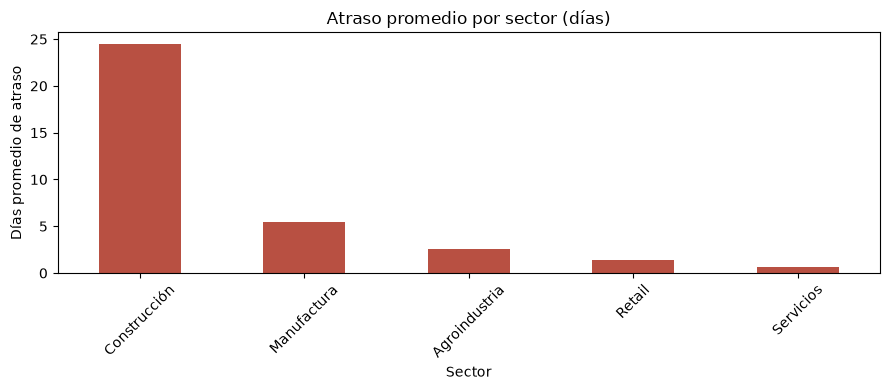

In [43]:
import matplotlib.pyplot as plt

# Gráfico 1: atraso promedio por sector
riesgo_sector["atraso_promedio"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 4),
    color="#B85042",
    title="Atraso promedio por sector (días)"
)

plt.xlabel("Sector")
plt.ylabel("Días promedio de atraso")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## promnt
### Puedes crear dos gráficos para el Reto 3
con esto concluimos que el sector construccion con un % de participacion de tiempo tardio del 76% un porcentaje y un atraso promedio de 25 dias bastante elevado el % sin embargo la edad cartera no es critica es bueno validar la demora en los atrasos de pago de sus facturas y si especialmente en este sector el atraso es justificado.

In [44]:
# Reto 4
# Prompt usado:
# "Asume el rol de analista de datos. Tengo un DataFrame llamado df
# con las columnas cliente, valor_factura, fecha_pago y factura_id.
# Selecciona cinco clientes para ofrecerles un descuento por pronto pago.
# Usa como criterio una buena puntualidad historica, minimo cinco facturas
# pagadas y una facturación anual significativa. Calcula la facturación
# anual, el número de facturas pagadas, el atraso promedio y el porcentaje
# de pagos tardíos. Ordena los clientes recomendados."

# Seleccionar facturas pagadas
pagadas_clientes = df[df["fecha_pago"].notna()].copy()

# Calcular los días de atraso
pagadas_clientes["dias_atraso"] = (
    pagadas_clientes["fecha_pago"]
    - pagadas_clientes["fecha_vencimiento"]
).dt.days

# Identificar pagos tardíos: más de 5 días después del vencimiento
pagadas_clientes["pago_tarde"] = (
    pagadas_clientes["dias_atraso"] > 5
)

# Crear el perfil de cada cliente
perfil_descuento = (
    pagadas_clientes.groupby("cliente")
    .agg(
        facturacion_anual=("valor_factura", "sum"),
        facturas_pagadas=("factura_id", "count"),
        atraso_promedio=("dias_atraso", "mean"),
        porcentaje_pago_tarde=("pago_tarde", "mean")
    )
)

# Convertir la proporción a porcentaje
perfil_descuento["porcentaje_pago_tarde"] = (
    perfil_descuento["porcentaje_pago_tarde"] * 100
).round(1)

# Conservar clientes con una historia mínima de cinco facturas
clientes_elegibles = perfil_descuento[
    perfil_descuento["facturas_pagadas"] >= 5
].copy()

# Ordenar: menor porcentaje tardío, menor atraso y mayor facturación
clientes_recomendados = (
    clientes_elegibles
    .sort_values(
        by=[
            "porcentaje_pago_tarde",
            "atraso_promedio",
            "facturacion_anual"
        ],
        ascending=[True, True, False]
    )
    .head(5)
)

# Mostrar la facturación en millones
clientes_recomendados["facturacion_millones"] = (
    clientes_recomendados["facturacion_anual"] / 1e6
).round(1)

clientes_recomendados

,facturacion_anual,facturas_pagadas,atraso_promedio,porcentaje_pago_tarde,facturacion_millones
cliente,,,,,
Insumos Agrícolas Llanos,165500000,19,-1.052632,5.3,165.5
Servicios Logísticos Andinos,94000000,15,-1.400000,6.7,94.0
Tecnología Andina,210700000,24,1.875000,16.7,210.7
Droguería Vital,101600000,15,-0.533333,20.0,101.6
Metalmecánica Bolívar,201700000,14,1.285714,21.4,201.7


la empresa quiere ofrecer un descuento de pronto pago solo ha cinco clientes, para esto tenemos que validar el historial de pago de cada uno y su valor de facturacion cuales son los clientes mas representativos en las ventas de la compañia, si bien recordemos que la mayoria de atrasos y los mas significativos oscilan entre los 35 a 40 con los clientes seleccionados el mayor tiene un promedio de 21 dias nuevamente se usa un operador boleano para tener un limite de facturas que se valide con minimo 5 facturas pagadas y tiene una facturacion importante con la empresa por lo que probablemente permitira que la cartera sea positiva y la gestion igual

---
## Para llevar de esta sesión

- Los **cuatro tipos de analítica** son cuatro preguntas: ¿qué pasó?, ¿por qué?, ¿qué pasará?, ¿qué hacemos? El valor (y la dificultad) crece en ese orden.
- **pandas = Excel programable**: `read_csv`, `groupby`, `pivot_table` y filtros cubren el 80 % del trabajo descriptivo y diagnóstico.
- La **IA es tu copiloto de código**, no tu reemplazo de criterio: escribe el prompt con contexto, lee lo que devuelve y **verifica contra una cifra que ya conoces**.
- Próxima sesión (28 de agosto): visualización profesional, K-means y nuestros primeros modelos de regresión. **Quiz 1 al inicio** sobre los conceptos de hoy. 📌